In [1]:
import sys
from pathlib import Path

import numpy as np

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [2]:
import scanpy as sc

adata = sc.read_h5ad("outputs/adata/pancreas_processed.h5ad")

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.diffmap(adata)

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


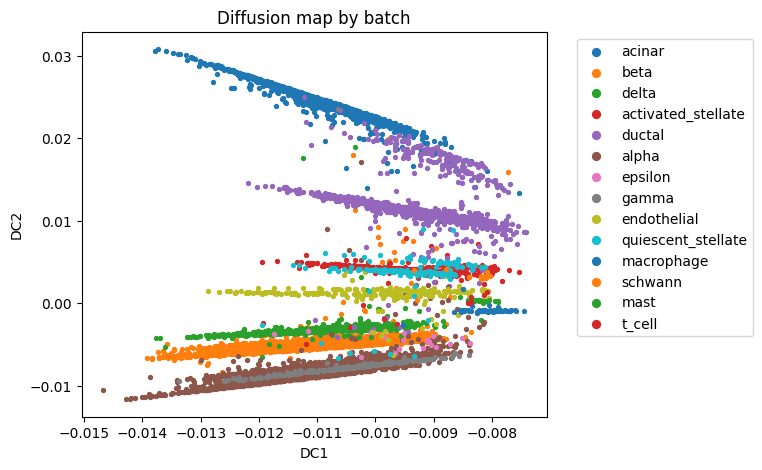

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
for b in adata.obs["assigned_cluster"].astype(str).unique():
    mask = adata.obs["assigned_cluster"].astype(str) == b
    plt.scatter(
        adata.obsm["X_diffmap"][mask, 0],
        adata.obsm["X_diffmap"][mask, 1],
        s=8,
        label=b,
    )
plt.xlabel("DC1")
plt.ylabel("DC2")
plt.title("Diffusion map by batch")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Text(0, 0.5, 'eigenvalue')

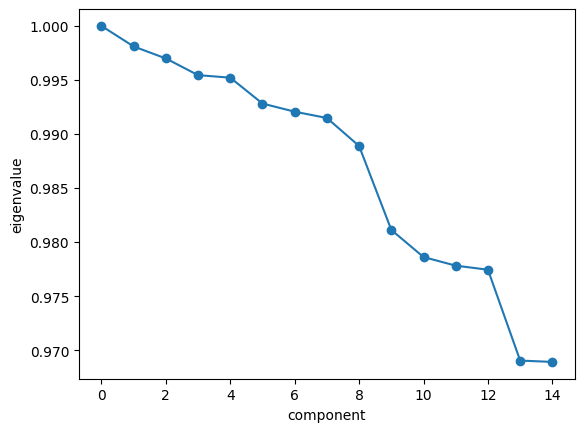

In [5]:
adata.uns["diffmap_evals"]

plt.plot(adata.uns["diffmap_evals"], "o-")
plt.xlabel("component")
plt.ylabel("eigenvalue")

## Analiza po assigned_cluster

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


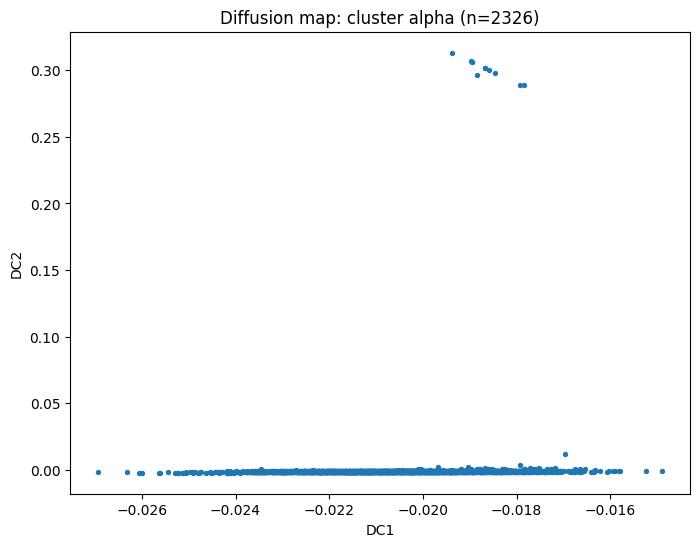

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


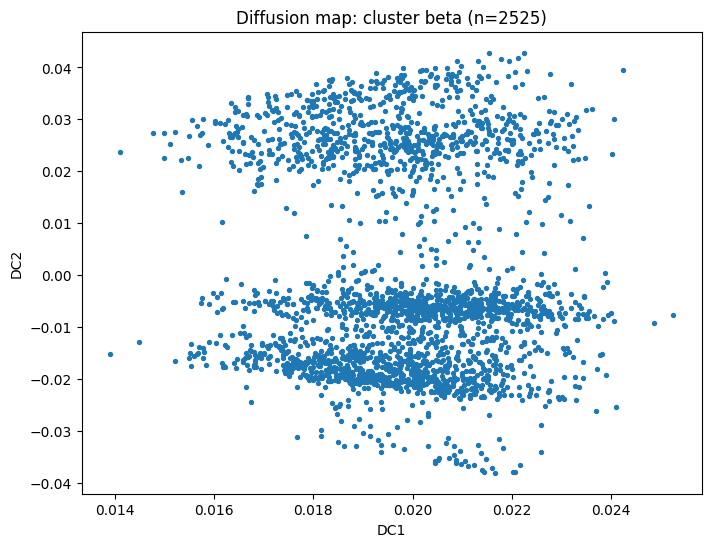

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


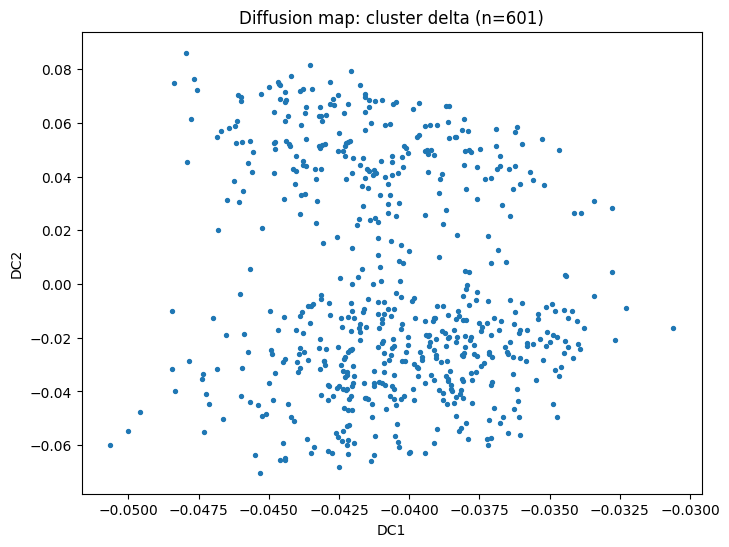

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


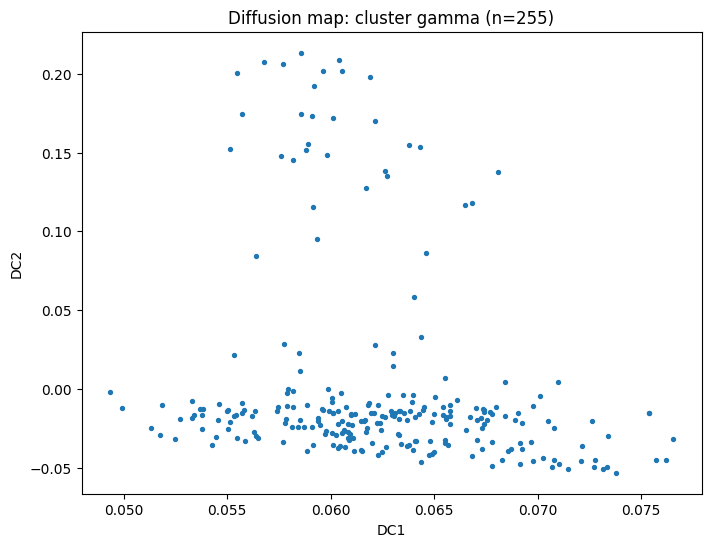

In [10]:
from src.geometric import plot_diffmap_per_cluster

plot_diffmap_per_cluster(
    adata,
    cluster_key="assigned_cluster",
    use_rep="X_pca",
    n_neighbors=10,
    min_cells=40,
    target_clusters=["alpha", "beta", "delta", "gamma"],
)

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


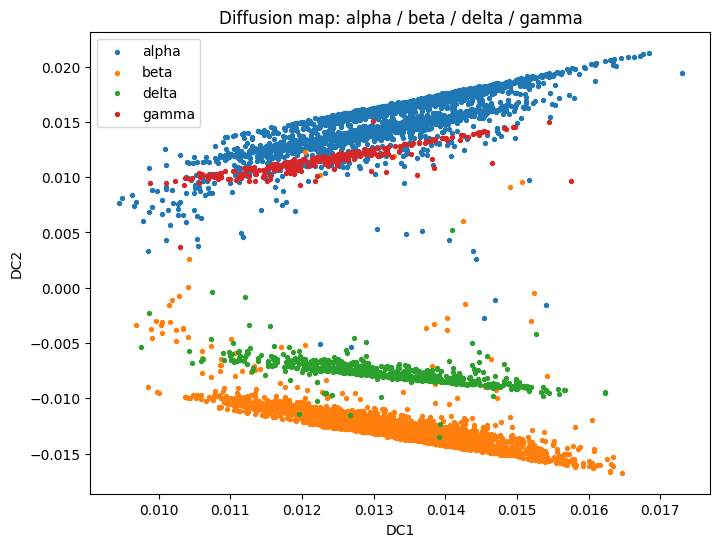

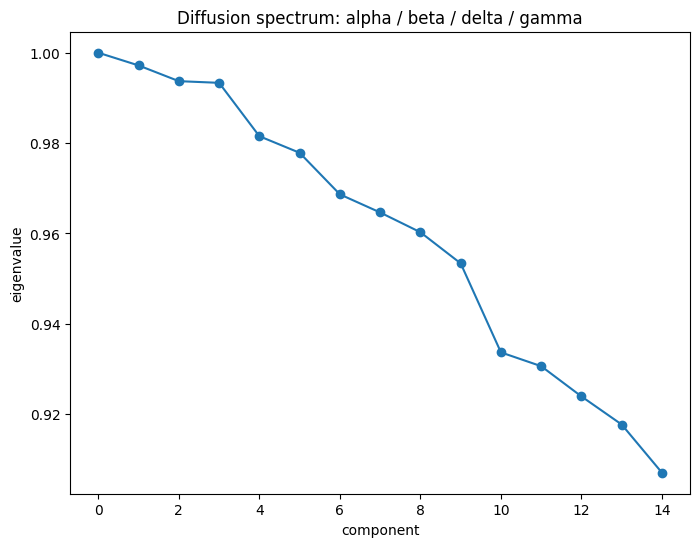

In [5]:
from src.geometric import plot_diffmap_for_selected_clusters

ad_endo = plot_diffmap_for_selected_clusters(
    adata,
    target_clusters=["alpha", "beta", "delta", "gamma"],
    cluster_key="assigned_cluster",
    use_rep="X_pca",
    n_neighbors=15,
)